<a href="https://colab.research.google.com/github/Omarctr/Machine-Learning/blob/main/housingDataCleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/train.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

<Axes: >

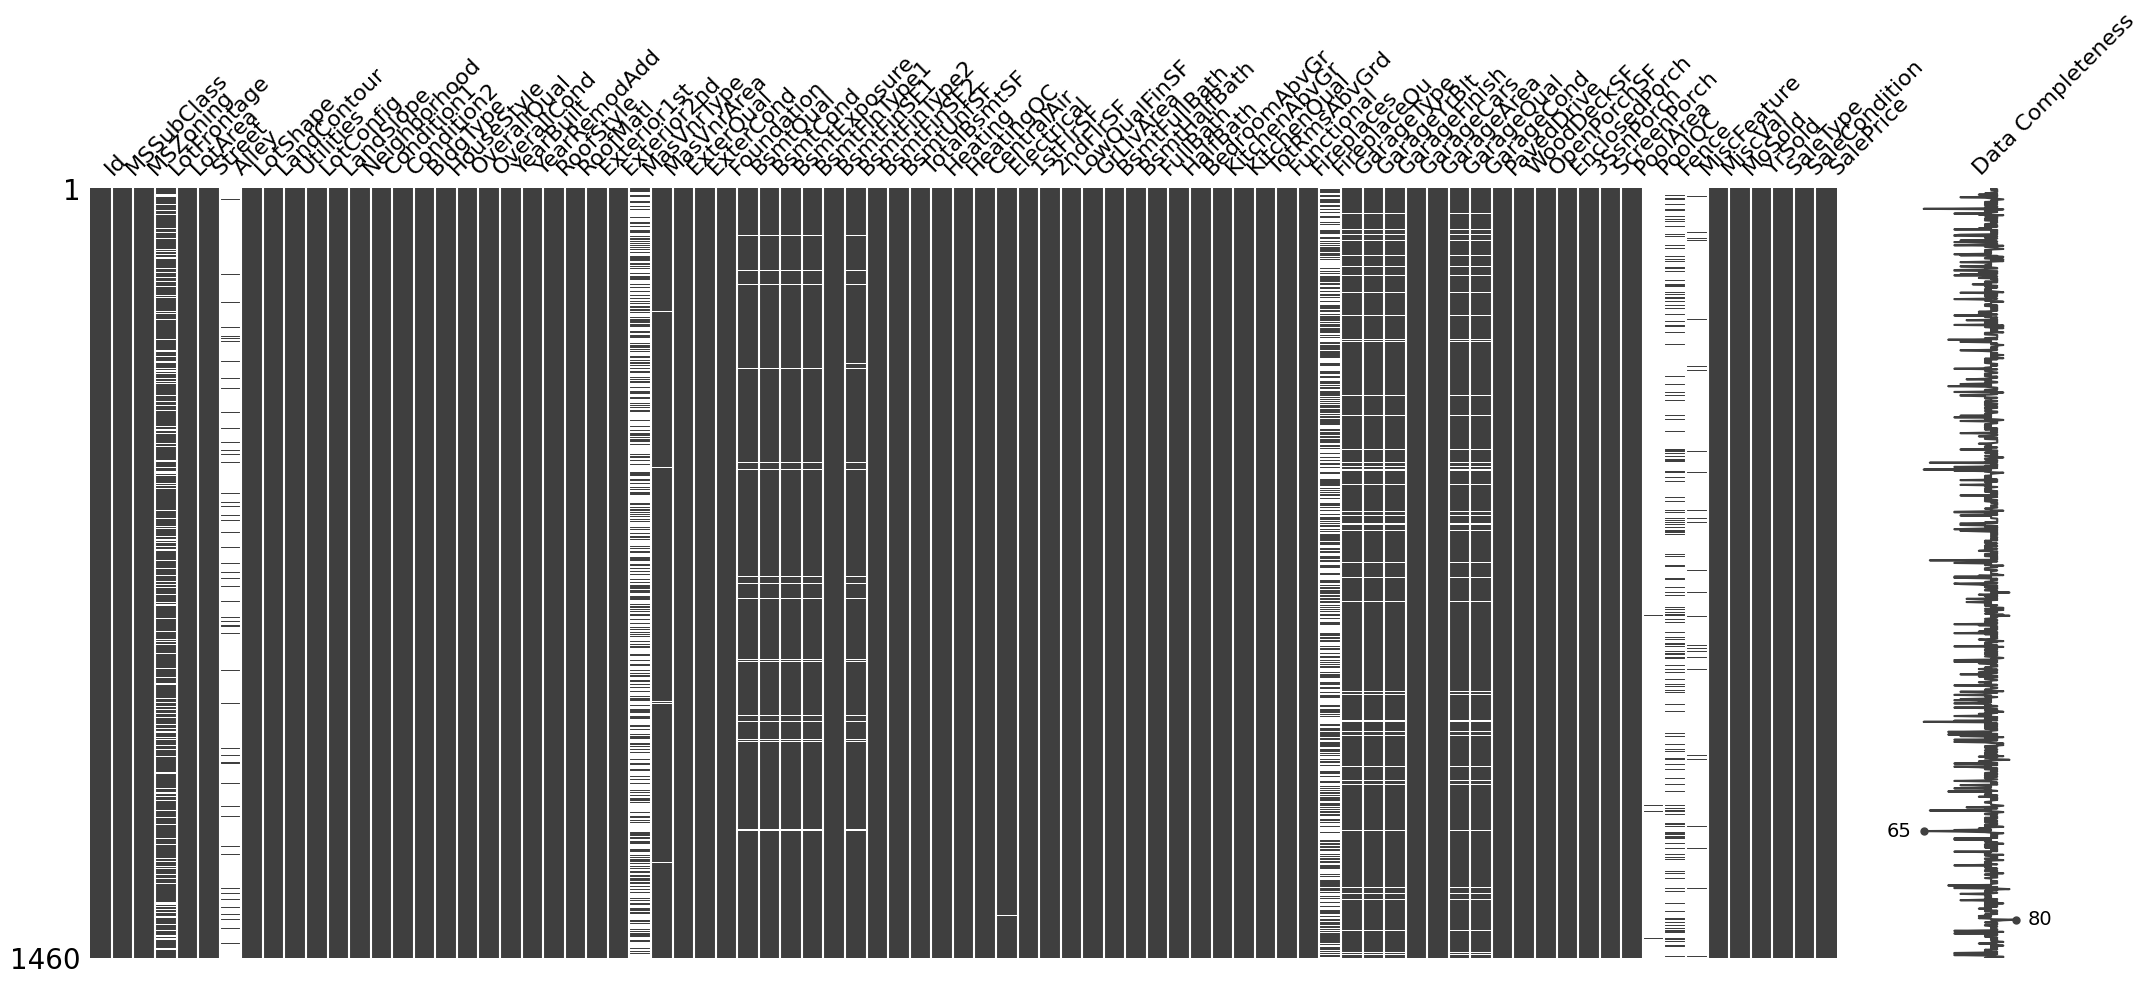

In [ ]:
import missingno as mo
mo.matrix(df, labels=True)

<Axes: >

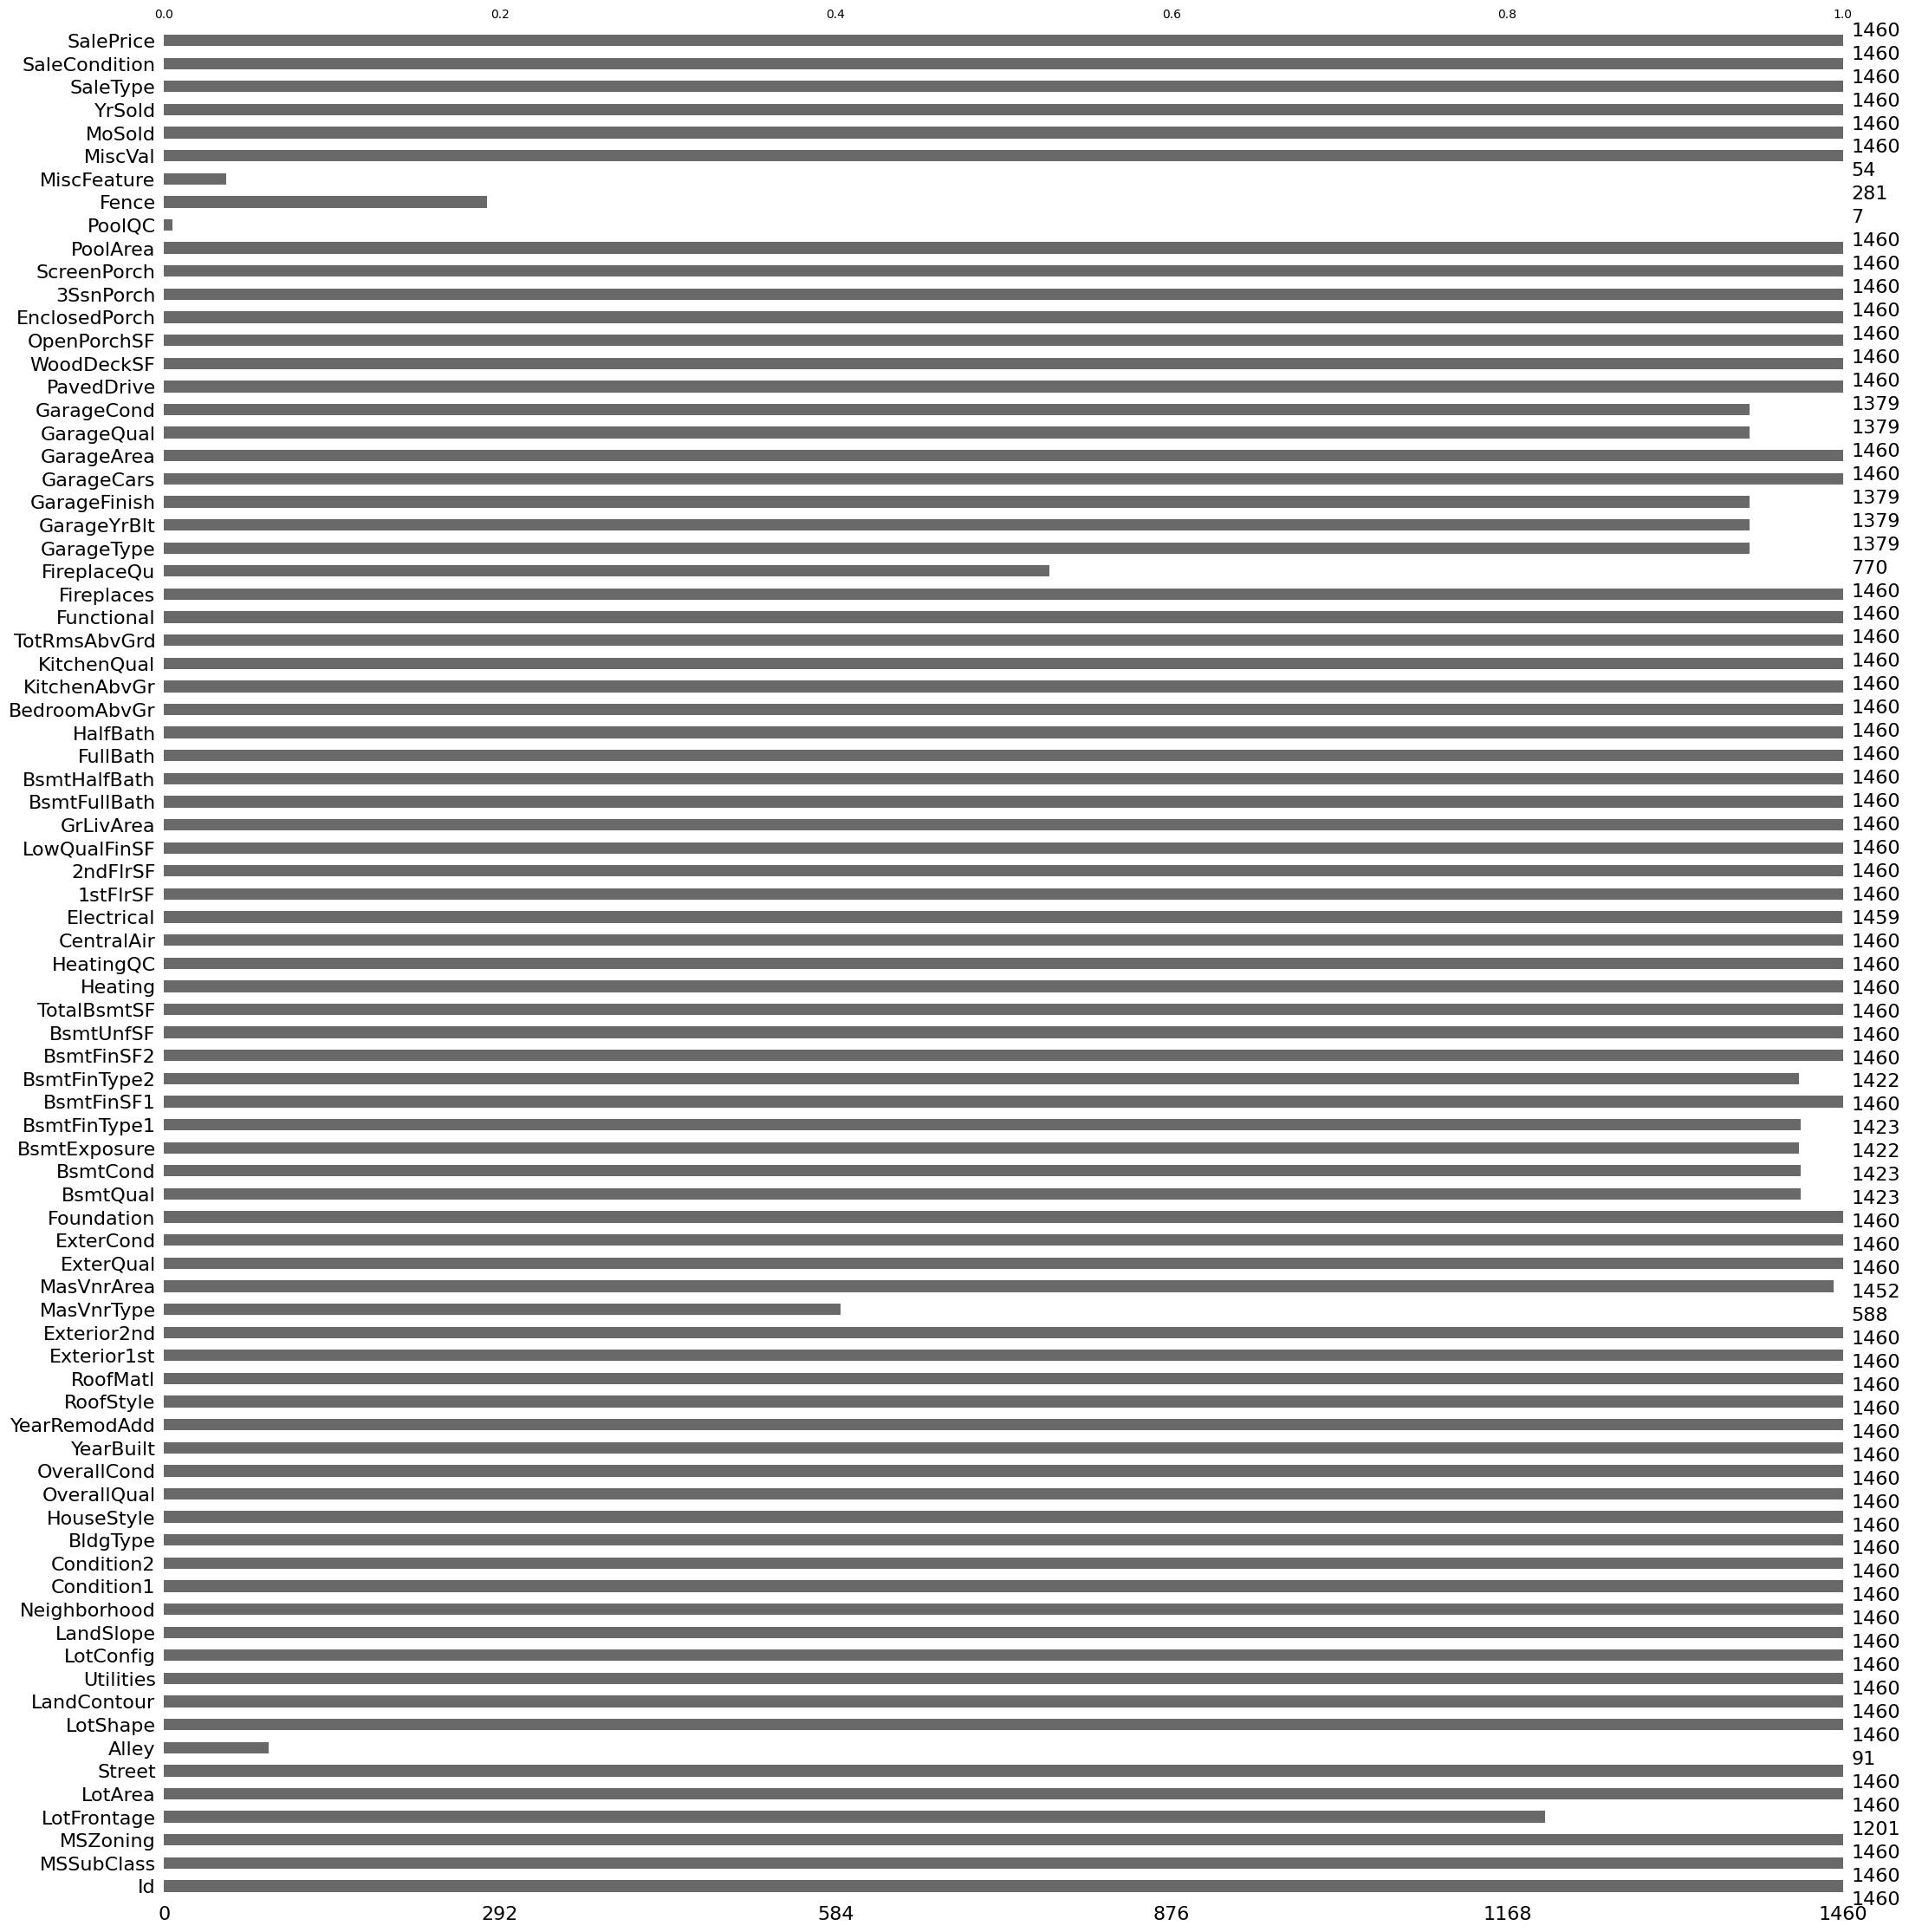

In [ ]:
mo.bar(df)

In [ ]:
df.isna().mean().sort_values(ascending=False).head(20)

,0
PoolQC,0.995205
MiscFeature,0.963014
Alley,0.937671
Fence,0.807534
MasVnrType,0.597260
FireplaceQu,0.472603
LotFrontage,0.177397
GarageQual,0.055479
GarageFinish,0.055479
GarageType,0.055479


In [ ]:
useless_columns = [
    'Id', 'Utilities', 'Street', 'Condition2', 'RoofMatl', 'Heating',
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

df.drop(columns= useless_columns, inplace = True)

In [ ]:
fill = df['LotFrontage'].median()
df['LotFrontage'] = df['LotFrontage'].fillna(fill)
fill = df['GarageYrBlt'].mode()[0]
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(fill)

In [ ]:
df['IsRemodeled'] = df['YearBuilt'] != df['YearRemodAdd']

In [ ]:
df.describe()


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,69.863699,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,22.027677,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,IsRemodeled
0,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,Norm,...,0,0,0,0,2,2008,WD,Normal,208500,False
1,20,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,Feedr,...,0,0,0,0,5,2007,WD,Normal,181500,False
2,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,Norm,...,0,0,0,0,9,2008,WD,Normal,223500,True
3,70,RL,60.0,9550,IR1,Lvl,Corner,Gtl,Crawfor,Norm,...,0,0,0,0,2,2006,WD,Abnorml,140000,True
4,60,RL,84.0,14260,IR1,Lvl,FR2,Gtl,NoRidge,Norm,...,0,0,0,0,12,2008,WD,Normal,250000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Reg,Lvl,Inside,Gtl,Gilbert,Norm,...,0,0,0,0,8,2007,WD,Normal,175000,True
1456,20,RL,85.0,13175,Reg,Lvl,Inside,Gtl,NWAmes,Norm,...,0,0,0,0,2,2010,WD,Normal,210000,True
1457,70,RL,66.0,9042,Reg,Lvl,Inside,Gtl,Crawfor,Norm,...,0,0,0,2500,5,2010,WD,Normal,266500,True
1458,20,RL,68.0,9717,Reg,Lvl,Inside,Gtl,NAmes,Norm,...,0,0,0,0,4,2010,WD,Normal,142125,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 61 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   LotShape       1460 non-null   object 
 5   LandContour    1460 non-null   object 
 6   LotConfig      1460 non-null   object 
 7   LandSlope      1460 non-null   object 
 8   Neighborhood   1460 non-null   object 
 9   Condition1     1460 non-null   object 
 10  BldgType       1460 non-null   object 
 11  HouseStyle     1460 non-null   object 
 12  OverallQual    1460 non-null   int64  
 13  OverallCond    1460 non-null   int64  
 14  YearBuilt      1460 non-null   int64  
 15  YearRemodAdd   1460 non-null   int64  
 16  RoofStyle      1460 non-null   object 
 17  Exterior1st    1460 non-null   object 
 18  Exterior

In [ ]:
v = pd.get_dummies(df.MSZoning, drop_first=True)
df = pd.concat([df, v], axis = 1)

In [ ]:
df.drop(columns = ['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1'], inplace = True)

In [ ]:
df.drop(columns = ['BldgType', 'YearRemodAdd', 'RoofStyle', 'SaleType', 'SaleCondition'], inplace = True)

In [ ]:
df.drop(columns = ['Exterior1st', 'Exterior2nd'], inplace = True)

In [ ]:
df.drop(columns = ['ExterQual', 'ExterCond', 'Foundation', 'HeatingQC', 'Electrical', 'KitchenQual', 'HouseStyle'], inplace = True)

In [ ]:
df.drop(columns = ['Functional','GarageCars'], inplace = True)

In [ ]:
df.PavedDrive = df.PavedDrive.map({'Y' : 1, 'N' : 0})
df.CentralAir = df.CentralAir.map({'Y' : 1, 'N' : 0})

In [ ]:
df.dropna(subset = ['MasVnrArea'], inplace=True)
df.PavedDrive = df.PavedDrive.fillna(0)

<Axes: >

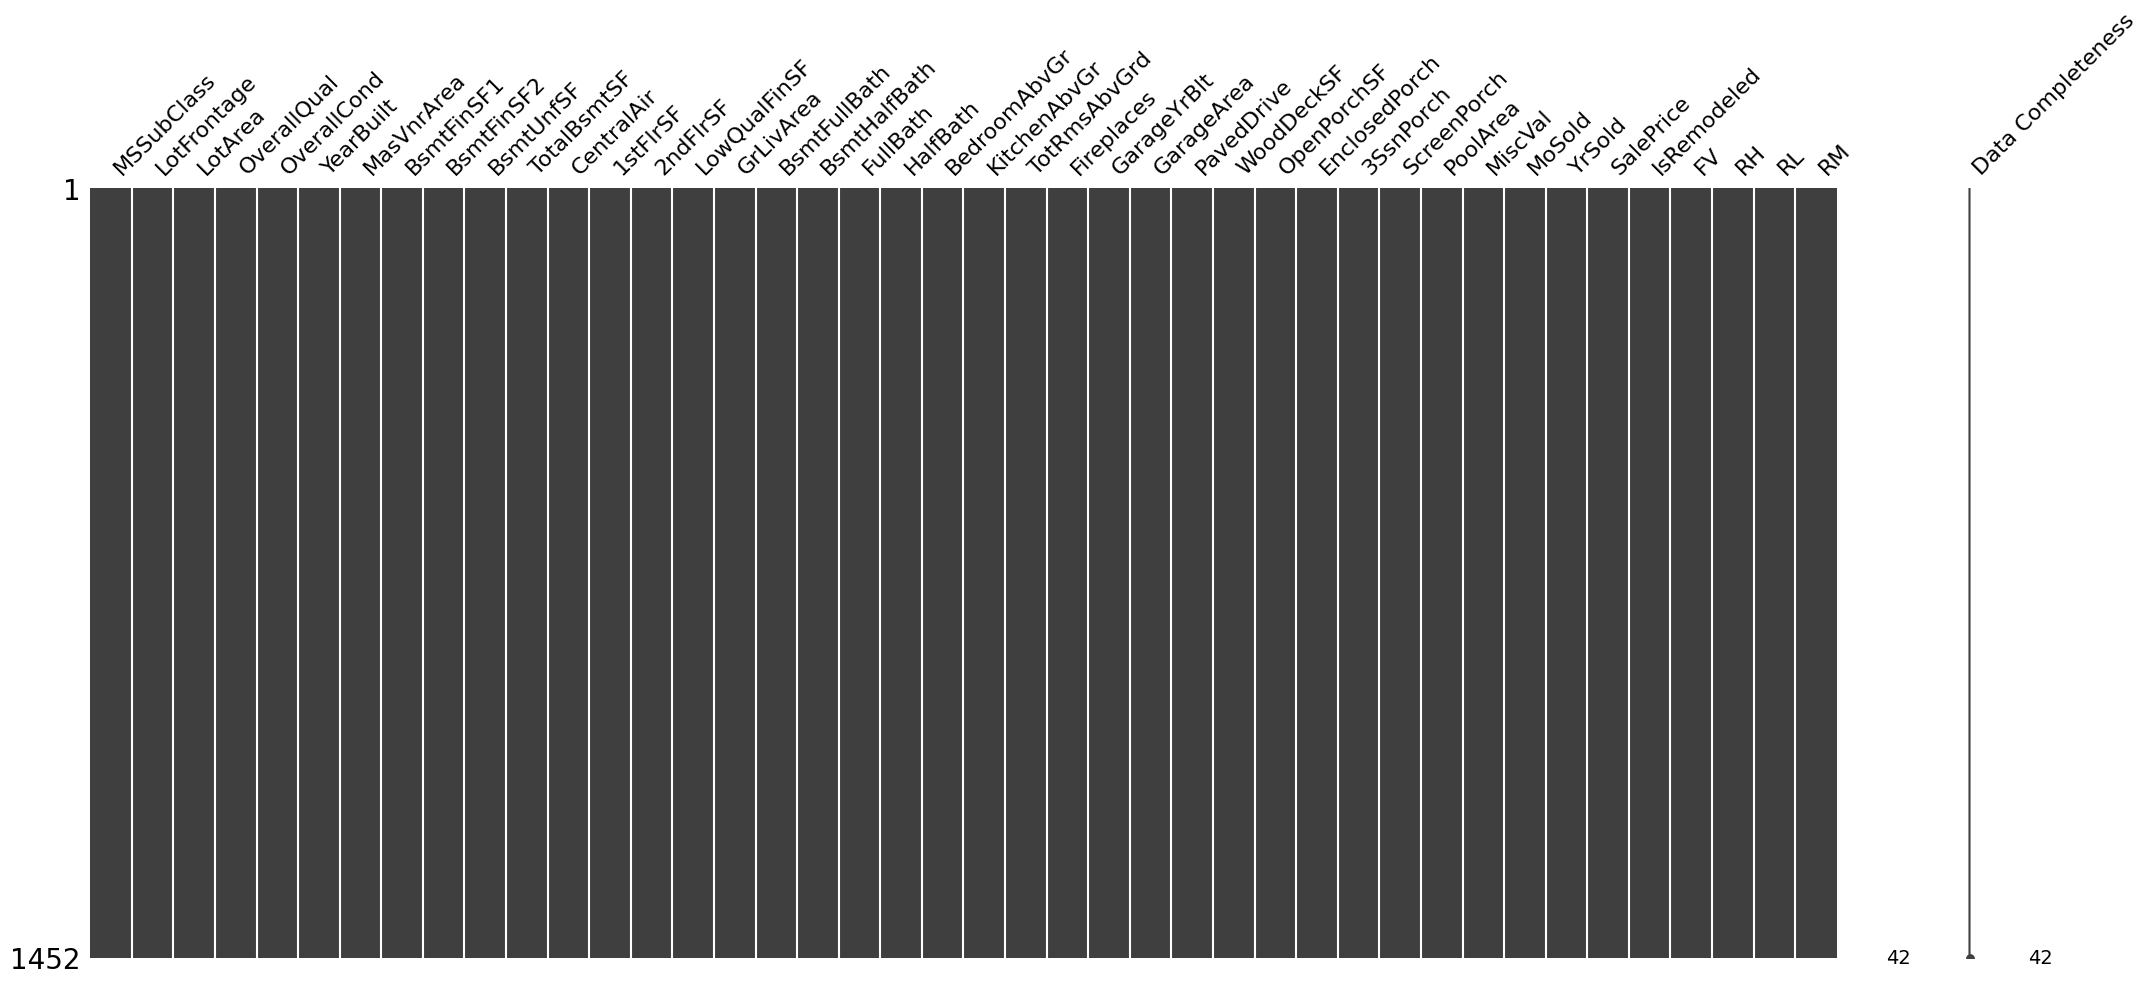

In [ ]:
mo.matrix(df, labels = True)

<Axes: >

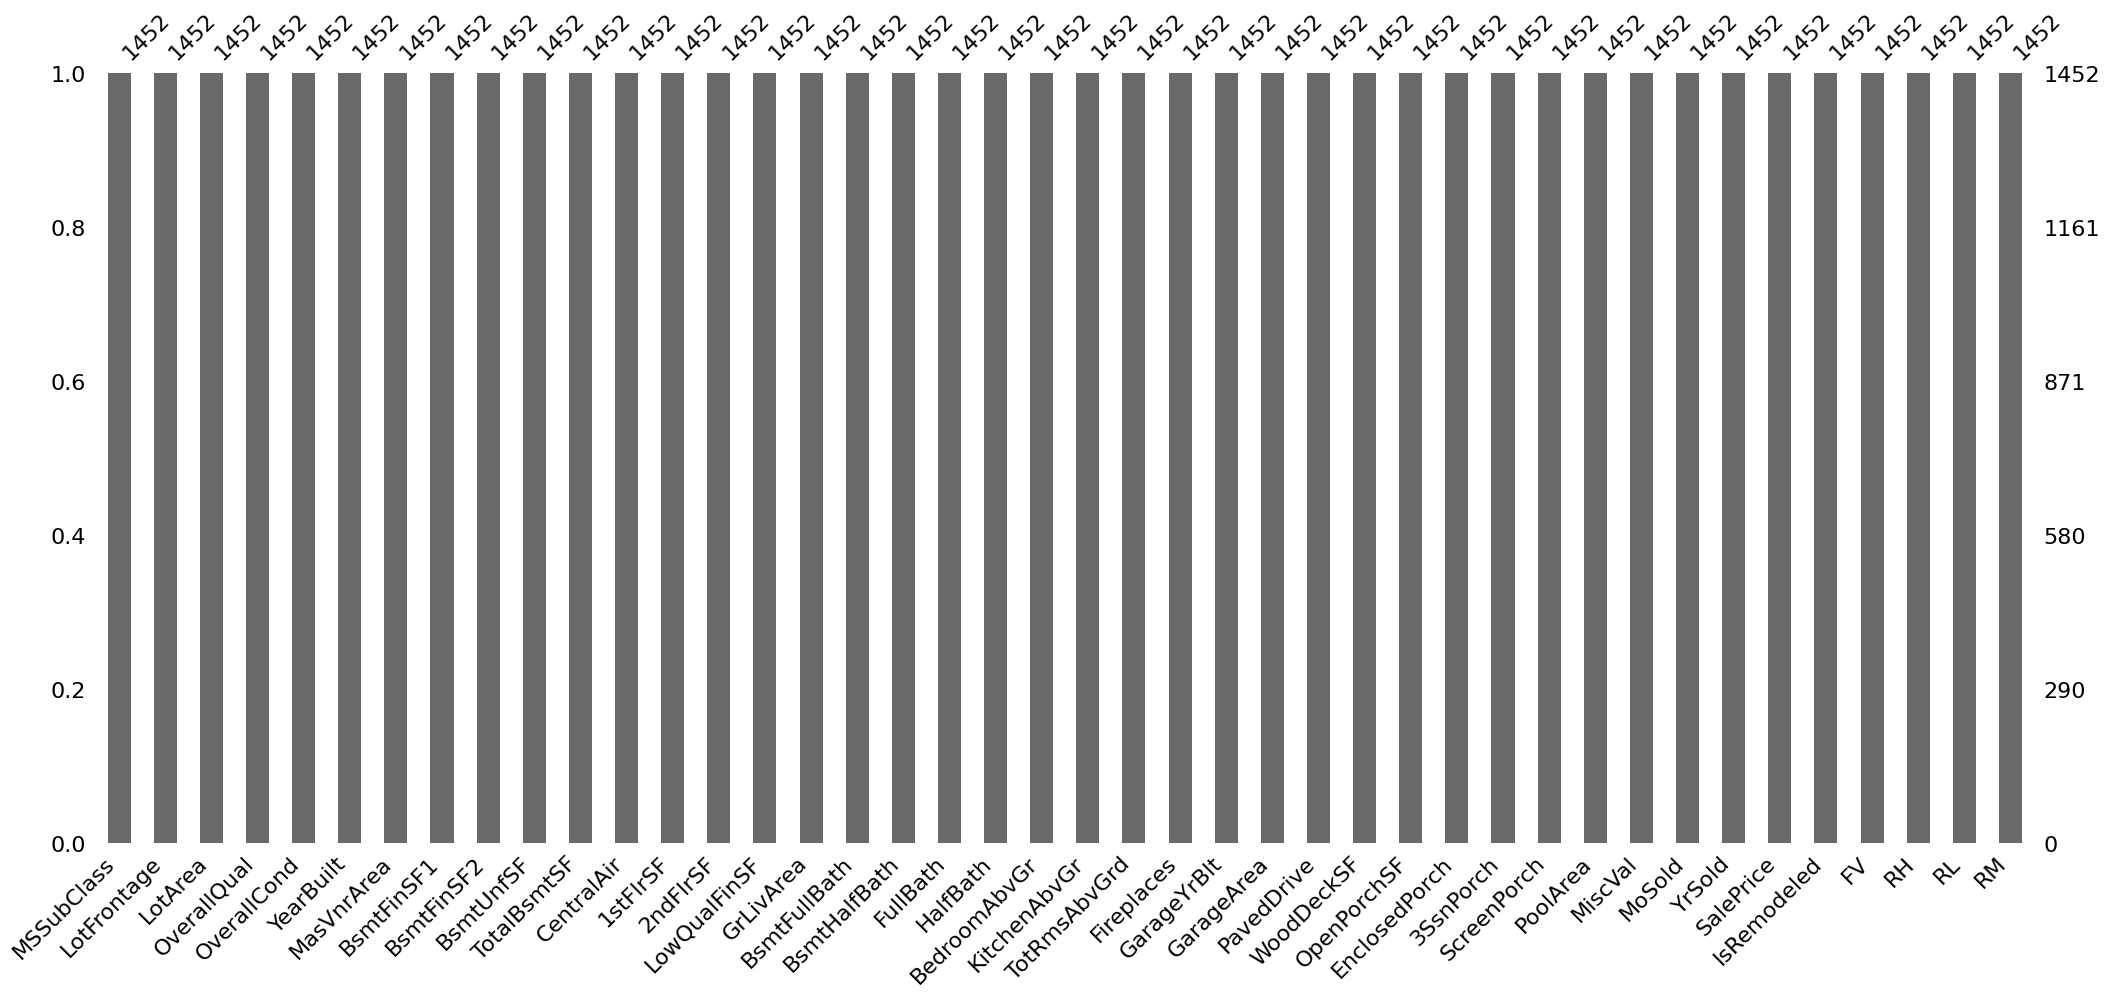

In [ ]:
mo.bar(df)

In [ ]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model = RandomForestRegressor()


lr = Pipeline([
    ('scaler' , StandardScaler()),
               ('model' , LinearRegression())])

x = df.drop(columns = 'SalePrice')
y = df.SalePrice

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

print(sum(cross_val_score(model, x_train, y_train, cv = 5)) / 5)
print(sum(cross_val_score(lr,  x_train, y_train, cv = 5)) / 5)

model.fit(x_train, y_train)
model.score(x_test, y_test)


0.8455795199936302
0.7496944802937978


0.8680806716911567

In [ ]:
# house year build vs price
yvp = df.groupby('YearBuilt')['SalePrice'].median().sort_values(ascending=False)
for y,p in yvp.items():
  print(f'{y}: {p}$')

2010: 394432.0$
2008: 335000.0$
1893: 325000.0$
1892: 291250.0$
1989: 275000.0$
2007: 245000.0$
2006: 239799.0$
1995: 238000.0$
1932: 229500.0$
1981: 228000.0$
2009: 226978.0$
2001: 226500.0$
2002: 221000.0$
1996: 212000.0$
1998: 211000.0$
2003: 208000.0$
1997: 207600.0$
1990: 206250.0$
1994: 205000.0$
2000: 199750.0$
2005: 199750.0$
1988: 196500.0$
1880: 194989.5$
1993: 194500.0$
1999: 191000.0$
2004: 191000.0$
1986: 190000.0$
1992: 189000.0$
1934: 188700.0$
1918: 185000.0$
1908: 183500.0$
1985: 180000.0$
1991: 179200.0$
1987: 179000.0$
1974: 170000.0$
1919: 169000.0$
1882: 168000.0$
1964: 167000.0$
1923: 165000.0$
1905: 163000.0$
1984: 162500.0$
1942: 162000.0$
1977: 160875.0$
1904: 157500.0$
1968: 156000.0$
1966: 155000.0$
1960: 154300.0$
1969: 154000.0$
1978: 152750.0$
1976: 150900.0$
1980: 147500.0$
1921: 147450.0$
1957: 145000.0$
1928: 145000.0$
1959: 144000.0$
1962: 143900.0$
1979: 142953.0$
1890: 142200.0$
1953: 142000.0$
1975: 141875.0$
1965: 141300.0$
1958: 139500.0$
1963: 13

In [ ]:
#does month actually effect the price?
df.groupby('MoSold')['SalePrice'].median().sort_values(ascending = False)
#the prices are near to eachother so it does not really effect the price

,SalePrice
MoSold,
9,182950.0
12,175500.0
8,173900.0
2,173250.0
11,170500.0
7,165195.0
3,163200.0
6,163000.0
10,159000.0


In [ ]:
#see if the prices increases if the house is remodeled
rem = df.groupby('IsRemodeled')['SalePrice'].median()
for check, p in rem.items():
  if check:
    print(f'The average prize of the remodeled house is: {p}$')
  else:
    print(f'the average prize of the house that didnt get remodeled: {p}$')


the average prize of the house that didnt get remodeled: 169500.0$
The average prize of the remodeled house is: 155000.0$


In [ ]:
test = pd.read_csv('/content/test.csv')

test

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal
